# Deep Learning
## Lab Assignment 1 - Principle Component Analysis
Name: Ruta Lole

Roll no.: 61

PRN: 12310305

Class: TY CSAI-A

Batch: 3

## Title: Perform PCA in dimension reduction of numerical data
1.   Pre-process the data through standardization.
2.   Perform PCA to reduce dimension.
3.   Construct the scree plot.
4.   Data visualization in lower dimensional representation.

## Load Data

In [ ]:
import pandas as pd

df = pd.read_csv('/content/train.csv')
print("DataFrame 'df' loaded successfully. Displaying the first 5 rows:")
df.head()

DataFrame 'df' loaded successfully. Displaying the first 5 rows:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## Preprocess Numerical Data

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Exclude 'price_range' from numerical columns as it is the target variable
numerical_features = numerical_cols.drop('price_range')

# Create a copy of the DataFrame to store scaled data
df_scaled = df.copy()

# Create an instance of StandardScaler
scaler = StandardScaler()

# Apply the scaler to the identified numerical columns
df_scaled[numerical_features] = scaler.fit_transform(df[numerical_features])

print("Numerical columns identified and standardized. Displaying the first 5 rows of df_scaled:")
df_scaled.head()

Numerical columns identified and standardized. Displaying the first 5 rows of df_scaled:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,...,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097,1
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,...,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099,2
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,...,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099,2
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,...,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099,2
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,...,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099,1


## Perform PCA

In [ ]:
from sklearn.decomposition import PCA

# Instantiate PCA with n_components=None to compute all principal components
pca_model = PCA(n_components=None)

# Apply PCA to the standardized numerical features
pca_components = pca_model.fit_transform(df_scaled[numerical_features])

print("PCA applied successfully. Shape of pca_components:", pca_components.shape)

PCA applied successfully. Shape of pca_components: (2000, 20)


## Construct Scree Plot

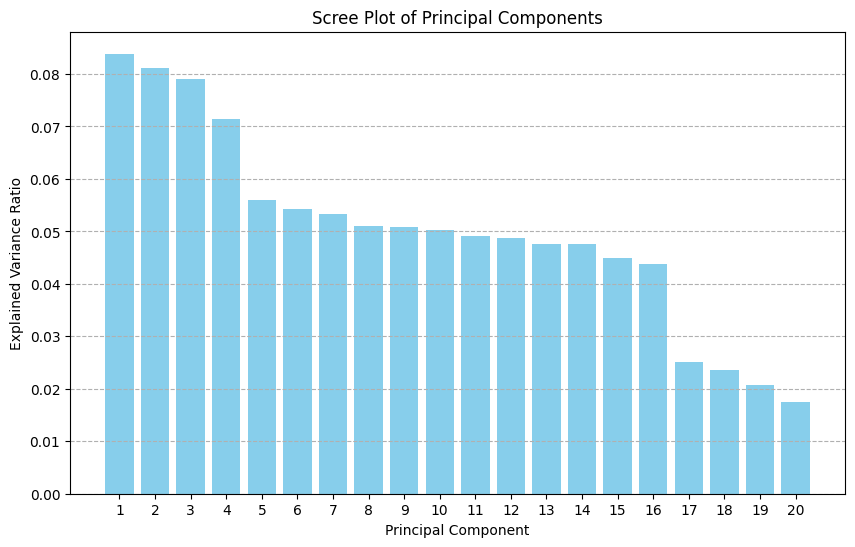

In [ ]:
import matplotlib.pyplot as plt

# Get explained variance ratio
explained_variance_ratio = pca_model.explained_variance_ratio_

# Create a list of component numbers for the x-axis
components = range(1, len(explained_variance_ratio) + 1)

# Generate the scree plot
plt.figure(figsize=(10, 6))
plt.bar(components, explained_variance_ratio, color='skyblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot of Principal Components')
plt.xticks(components)
plt.grid(axis='y', linestyle='--')
plt.show()

## Visualize Lower Dimensional Data

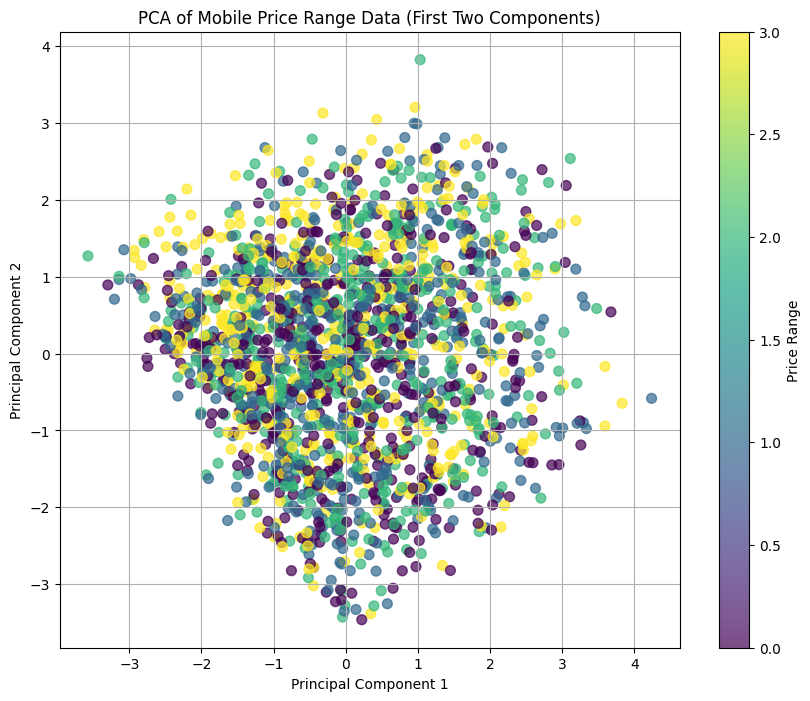

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a new DataFrame with the first two principal components
df_pca_2d = pd.DataFrame(data=pca_components[:, 0:2], columns=['PC1', 'PC2'])

# Add the 'price_range' column from the original df to df_pca_2d
df_pca_2d['price_range'] = df['price_range']

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(df_pca_2d['PC1'], df_pca_2d['PC2'], c=df_pca_2d['price_range'], cmap='viridis', s=50, alpha=0.7)

# Add title and labels
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Mobile Price Range Data (First Two Components)')

# Add a color bar/legend
cbar = plt.colorbar()
cbar.set_label('Price Range')

plt.grid(True)
plt.show()

## Summary:
PCA was successfully applied to 20 standardized numerical features, yielding 20 principal components. The `pca_components` array has a shape of (2000, 20), representing the reduced-dimension data.

The scree plot visualizes the explained variance ratio for each principal component, allowing for the identification of components that capture the most variance and helping to determine an optimal number of components by observing where the explained variance ratio sharply decreases (the 'elbow' point).

The scatter plot of the first two principal components (PC1 and PC2), colored by `price_range`, effectively distinguishes between different price categories. This suggests that even with only two principal components, there is some discernible separation among the price ranges, indicating that PCA can help in visualizing and potentially classifying these categories.

### Data Analysis Key Findings
*   The `train.csv` dataset, containing 2000 rows and 21 columns, was successfully loaded.
*   20 numerical columns (excluding the target variable `price_range`) were identified and standardized using `StandardScaler`.
*   Principal Component Analysis (PCA) was applied to the 20 standardized numerical features, resulting in 20 principal components.
*   A scree plot was generated to display the explained variance ratio for each principal component, providing a visual aid for selecting the optimal number of components.
*   A 2D scatter plot of the first two principal components (PC1 and PC2) was created, with points colored by their `price_range`, showing effective distinction between different price categories.

